# Lab Activity: Decision Tree Classifier on the Iris Dataset

**Dataset:** Iris Dataset (`sklearn.datasets.load_iris()`)

This notebook completes all 10 tasks of the lab activity:
Dataset Exploration, Data Preparation, Building a Decision Tree, Visualizing the Tree,
Comparing Gini vs Entropy, Effect of `max_depth`, Effect of `min_samples_split`,
Effect of `min_samples_leaf`, Hyperparameter Tuning with GridSearchCV, and Analysis.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


---
## Task 1: Dataset Exploration


In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = list(iris.feature_names)
target_names = list(iris.target_names)

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['species'] = df['target'].map(dict(enumerate(target_names)))

n_samples, n_features = X.shape
print(f"1. Number of samples : {n_samples}")
print(f"   Number of features: {n_features}")


1. Number of samples : 150
   Number of features: 4


In [3]:
print("2. Feature names:")
for f in feature_names:
    print("   -", f)

print("\n   Target classes:")
for i, t in enumerate(target_names):
    print(f"   - {i}: {t}")


2. Feature names:
   - sepal length (cm)
   - sepal width (cm)
   - petal length (cm)
   - petal width (cm)

   Target classes:
   - 0: setosa
   - 1: versicolor
   - 2: virginica


In [4]:
print("3. First five records:")
df.drop(columns=['target']).head()


3. First five records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


4. Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


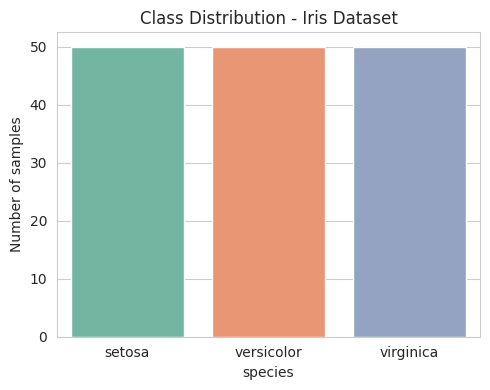

In [5]:
print("4. Class distribution:")
class_dist = df['species'].value_counts()
print(class_dist)

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='species', hue='species', palette='Set2', legend=False)
plt.title("Class Distribution - Iris Dataset")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()


**Observation:** The Iris dataset has **150 samples** and **4 features**
(sepal length, sepal width, petal length, petal width), with **3 target classes**
(setosa, versicolor, virginica), each perfectly balanced with **50 samples per class**.


---
## Task 2: Data Preparation


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/n_samples:.0%})")
print(f"Testing set size : {X_test.shape[0]} samples ({X_test.shape[0]/n_samples:.0%})")


Training set size: 120 samples (80%)
Testing set size : 30 samples (20%)


**Why split into training and testing sets?**

The dataset is divided into training and testing sets to evaluate how well a model
**generalizes to unseen data**, rather than just memorizing the data it was trained on.
The model learns patterns from the **training set (80%)**, and its performance is then
measured on the **testing set (20%)**, which it has never seen. This gives a realistic
estimate of real-world performance and helps detect **overfitting** — a model that
performs very well on training data but poorly on the test data is overfitting and has
not learned generalizable patterns. Using a fixed `random_state=42` also makes the split
reproducible, so results can be compared fairly across experiments.


---
## Task 3: Building a Decision Tree Classifier (default parameters)


In [7]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

y_pred_default = dt_default.predict(X_test)
print("Predicted labels:", y_pred_default)
print("Actual labels   :", y_test)


Predicted labels: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual labels   : [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [8]:
acc_default = accuracy_score(y_test, y_pred_default)
print(f"Accuracy Score: {acc_default:.4f} ({acc_default*100:.2f}%)")


Accuracy Score: 1.0000 (100.00%)


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


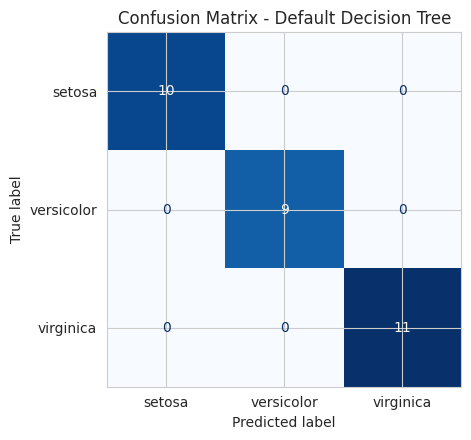

In [9]:
cm_default = confusion_matrix(y_test, y_pred_default)
print("Confusion Matrix:")
print(cm_default)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_default, display_labels=target_names)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix - Default Decision Tree")
plt.tight_layout()
plt.show()


In [10]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_default, target_names=target_names))


Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



---
## Task 4: Visualizing the Decision Tree


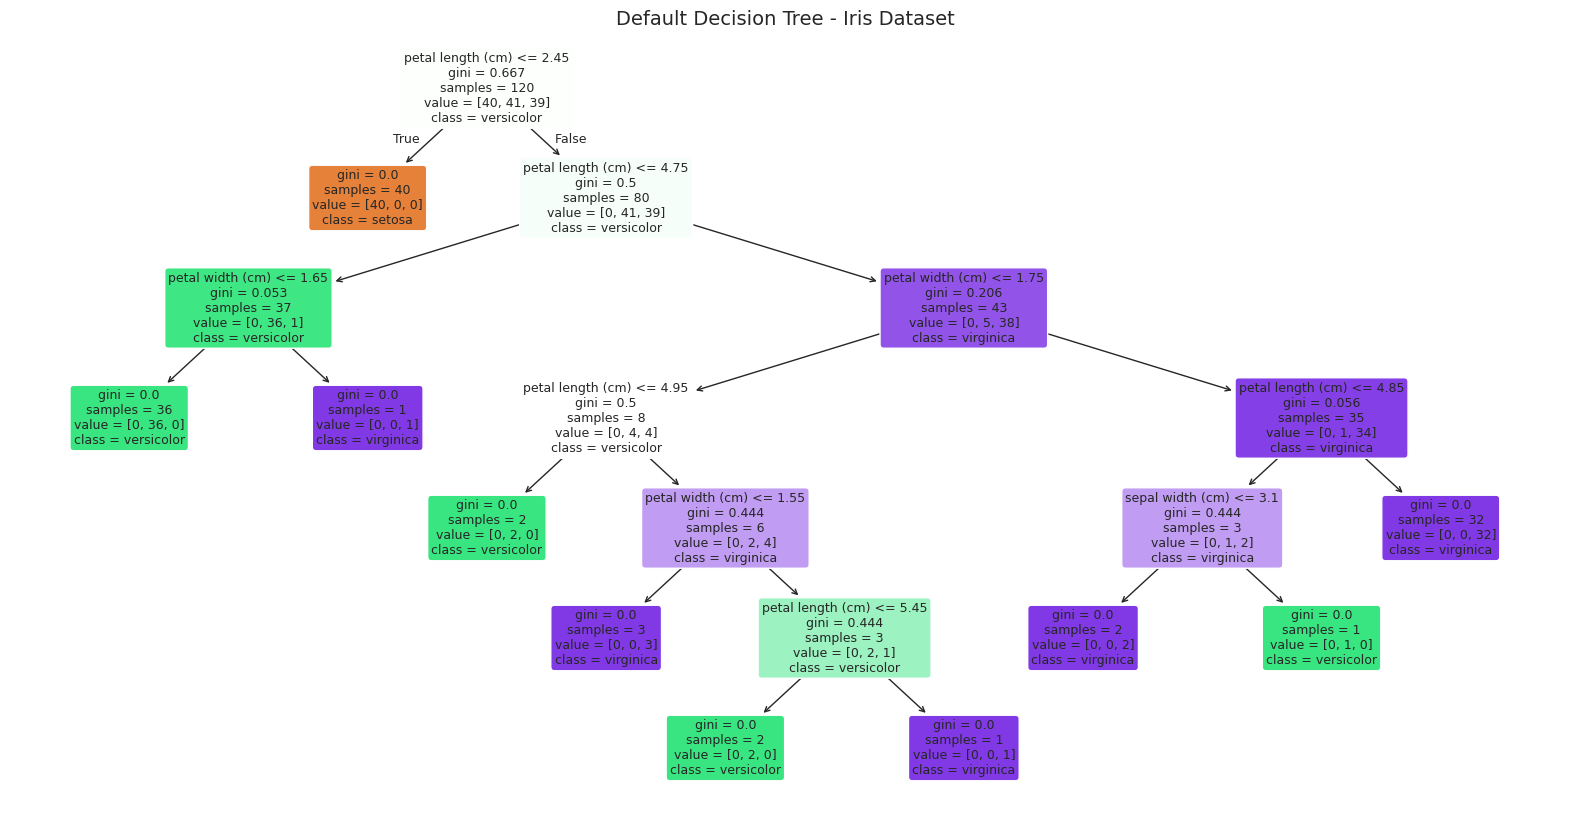

In [11]:
plt.figure(figsize=(20, 10))
plot_tree(dt_default, feature_names=feature_names, class_names=target_names,
          filled=True, rounded=True, fontsize=9)
plt.title("Default Decision Tree - Iris Dataset", fontsize=14)
plt.show()


In [12]:
n_nodes = dt_default.tree_.node_count
n_leaves = dt_default.get_n_leaves()
n_internal = n_nodes - n_leaves
max_depth = dt_default.get_depth()

root_feature_idx = dt_default.tree_.feature[0]
root_feature = feature_names[root_feature_idx]
root_threshold = dt_default.tree_.threshold[0]

print(f"Total nodes        : {n_nodes}")
print(f"Root node          : splits on '{root_feature}' <= {root_threshold:.2f}")
print(f"Internal nodes      (excluding root, including root as internal): {n_internal} "
      f"(1 root + {n_internal-1} other decision nodes)")
print(f"Leaf nodes          : {n_leaves}")
print(f"Maximum depth       : {max_depth}")

print("\nFeature importances (used to decide splits):")
for f, imp in sorted(zip(feature_names, dt_default.feature_importances_), key=lambda x: -x[1]):
    print(f"  {f:20s}: {imp:.4f}")


Total nodes        : 19
Root node          : splits on 'petal length (cm)' <= 2.45
Internal nodes      (excluding root, including root as internal): 9 (1 root + 8 other decision nodes)
Leaf nodes          : 10
Maximum depth       : 6

Feature importances (used to decide splits):
  petal length (cm)   : 0.9061
  petal width (cm)    : 0.0772
  sepal width (cm)    : 0.0167
  sepal length (cm)   : 0.0000


**Reading the visualization:**
- **Root node** — the top-most node of the tree, shown at depth 0. It contains all 120
  training samples and represents the very first decision the tree makes.
- **Internal (decision) nodes** — nodes that still test a feature/threshold and have
  children (they are not pure yet).
- **Leaf nodes** — terminal nodes (no children) where the tree assigns a final class
  label; these are reached once a subset of samples belongs (almost) entirely to one class
  (Gini/entropy ≈ 0), or a stopping condition is met.
- **Maximum depth** is printed above — this is how many decision levels are needed in
  the deepest branch of the tree before reaching a leaf.

**Which feature is selected for the first split, and why?**
The exact root feature is printed in the code output above. In the Iris dataset it is
almost always **petal length** or **petal width**. This happens because these two
features have the strongest separation between the three species (setosa is
linearly separable from the other two using petal measurements alone), so splitting on
them produces the largest reduction in impurity (highest Information Gain / Gini Gain)
compared to sepal length or sepal width — and `DecisionTreeClassifier` always chooses the
split that maximizes impurity reduction at each node.


---
## Task 5: Comparing Gini Index and Entropy


In [13]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)
y_pred_gini = dt_gini.predict(X_test)

dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)
y_pred_entropy = dt_entropy.predict(X_test)

acc_gini = accuracy_score(y_test, y_pred_gini)
acc_entropy = accuracy_score(y_test, y_pred_entropy)

root_feat_gini = feature_names[dt_gini.tree_.feature[0]]
root_feat_entropy = feature_names[dt_entropy.tree_.feature[0]]

comparison_df = pd.DataFrame({
    "Criterion": ["Gini", "Entropy"],
    "Accuracy": [round(acc_gini, 4), round(acc_entropy, 4)],
    "Tree Depth": [dt_gini.get_depth(), dt_entropy.get_depth()],
    "Number of Leaf Nodes": [dt_gini.get_n_leaves(), dt_entropy.get_n_leaves()],
    "Root Feature Selected": [root_feat_gini, root_feat_entropy]
})
comparison_df


,Criterion,Accuracy,Tree Depth,Number of Leaf Nodes,Root Feature Selected
0,Gini,1.0,6,10,petal length (cm)
1,Entropy,1.0,6,10,petal length (cm)


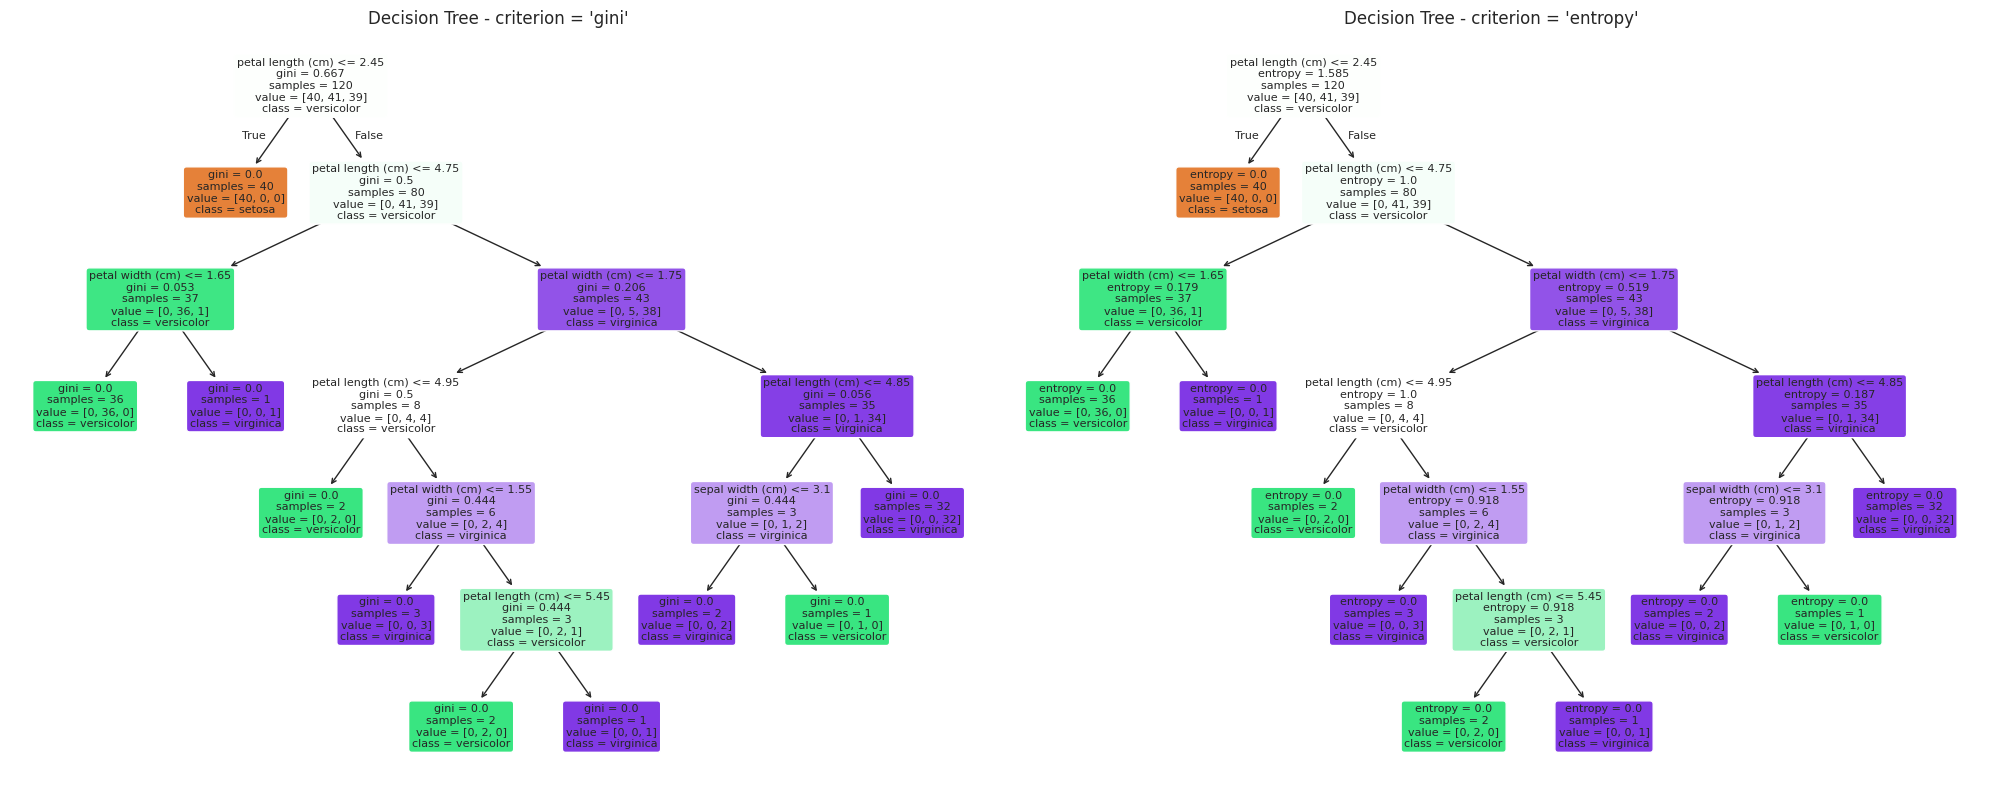

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
plot_tree(dt_gini, feature_names=feature_names, class_names=target_names,
          filled=True, rounded=True, fontsize=8, ax=axes[0])
axes[0].set_title("Decision Tree - criterion = 'gini'")

plot_tree(dt_entropy, feature_names=feature_names, class_names=target_names,
          filled=True, rounded=True, fontsize=8, ax=axes[1])
axes[1].set_title("Decision Tree - criterion = 'entropy'")
plt.tight_layout()
plt.show()


In [15]:
simpler = "Gini" if dt_gini.get_n_leaves() < dt_entropy.get_n_leaves() else (
    "Entropy" if dt_entropy.get_n_leaves() < dt_gini.get_n_leaves() else "Both are equally complex")
print(f"Criterion producing the simpler tree (fewer leaves): {simpler}")
print(f"(Gini leaves = {dt_gini.get_n_leaves()}, depth = {dt_gini.get_depth()} | "
      f"Entropy leaves = {dt_entropy.get_n_leaves()}, depth = {dt_entropy.get_depth()})")


Criterion producing the simpler tree (fewer leaves): Both are equally complex
(Gini leaves = 10, depth = 6 | Entropy leaves = 10, depth = 6)


**Summary (see table above for exact numbers):**
Gini Index and Entropy are both impurity measures and, on a well-separated dataset like
Iris, they usually select the **same root feature** and produce trees of very similar
accuracy — Gini is slightly cheaper to compute (no logarithms) which is why it's the
scikit-learn default, while Entropy/Information Gain is more sensitive to class-probability
changes. The criterion that produces the tree with fewer leaf nodes (printed above) is
considered the "simpler" tree for this run.


---
## Task 6: Effect of Maximum Tree Depth


In [16]:
depth_values = [1, 2, 3, 4, None]
depth_results = []

for d in depth_values:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    actual_depth = model.get_depth()

    if train_acc < 0.90:
        obs = "Underfitting - tree too shallow to capture patterns"
    elif train_acc - test_acc > 0.05:
        obs = "Possible overfitting - large train/test accuracy gap"
    else:
        obs = "Good balance between bias and variance"

    depth_results.append({
        "Max Depth": "None" if d is None else d,
        "Training Accuracy": round(train_acc, 4),
        "Testing Accuracy": round(test_acc, 4),
        "Tree Depth (actual)": actual_depth,
        "Observation": obs
    })

depth_df = pd.DataFrame(depth_results)
depth_df


,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth (actual),Observation
0,1,0.6750,0.6333,1,Underfitting - tree too shallow to capture pat...
1,2,0.9500,0.9667,2,Good balance between bias and variance
2,3,0.9583,1.0000,3,Good balance between bias and variance
3,4,0.9750,1.0000,4,Good balance between bias and variance
4,None,1.0000,1.0000,6,Good balance between bias and variance


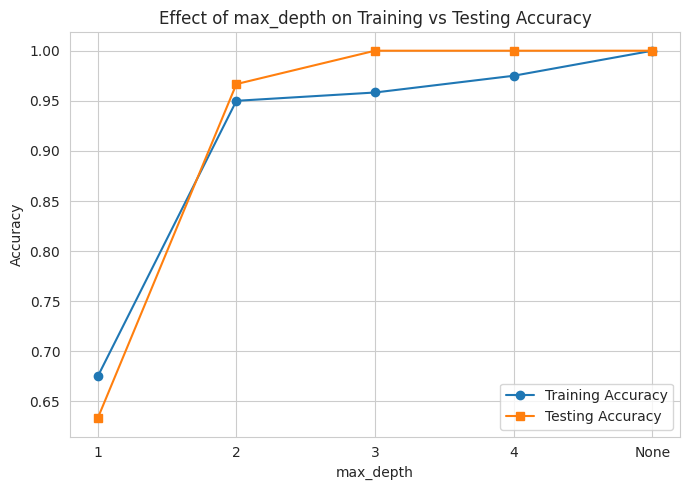

In [17]:
plt.figure(figsize=(7,5))
x_labels = [str(d) for d in depth_df["Max Depth"]]
plt.plot(x_labels, depth_df["Training Accuracy"], marker='o', label="Training Accuracy")
plt.plot(x_labels, depth_df["Testing Accuracy"], marker='s', label="Testing Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Effect of max_depth on Training vs Testing Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
underfit_row = depth_df.loc[depth_df["Training Accuracy"].idxmin()]
best_gen_row = depth_df.loc[depth_df["Testing Accuracy"].idxmax()]
overfit_candidate = depth_df.iloc[-1]  # None (unrestricted) is the classic overfit candidate

print(f"Likely UNDERFITTING model     : max_depth = {underfit_row['Max Depth']} "
      f"(lowest training accuracy = {underfit_row['Training Accuracy']})")
print(f"Best GENERALIZATION model     : max_depth = {best_gen_row['Max Depth']} "
      f"(highest testing accuracy = {best_gen_row['Testing Accuracy']})")
print(f"Most likely to OVERFIT        : max_depth = {overfit_candidate['Max Depth']} "
      f"(training accuracy = {overfit_candidate['Training Accuracy']}, "
      f"tree depth = {overfit_candidate['Tree Depth (actual)']}, unrestricted growth)")


Likely UNDERFITTING model     : max_depth = 1 (lowest training accuracy = 0.675)
Best GENERALIZATION model     : max_depth = 3 (highest testing accuracy = 1.0)
Most likely to OVERFIT        : max_depth = None (training accuracy = 1.0, tree depth = 6, unrestricted growth)


**Analysis:**
1. **Underfitting model** — the model with `max_depth=1` (a decision stump) is the most
   likely to underfit: it can only make a single split, so it cannot capture the
   relationships needed to separate all three species, giving noticeably lower training
   accuracy (see table/printed output above).
2. **Best generalization** — the row with the highest **testing** accuracy (printed above)
   is typically achieved at a moderate depth (`max_depth=3` or `4`), since it is deep
   enough to separate the classes but not so deep that it starts fitting noise.
3. **Most likely to overfit** — `max_depth=None` (unrestricted growth) is most prone to
   overfitting. This lets the tree keep splitting until every leaf is pure (or has very
   few samples), which drives training accuracy to ~100% but can add unnecessary,
   noise-fitting branches. On Iris, since it's a small, clean, well-separated dataset,
   the overfitting effect is mild, but the printed tree depth/leaf count for `None` is
   the largest of all configurations, confirming higher model complexity.


---
## Task 7: Effect of `min_samples_split`


In [19]:
mss_values = [2, 5, 10, 20]
mss_results = []

for m in mss_values:
    model = DecisionTreeClassifier(min_samples_split=m, random_state=42)
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    depth = model.get_depth()
    leaves = model.get_n_leaves()

    obs = "More splits allowed -> more complex tree" if m <= 5 else "Fewer splits allowed -> simpler, more generalized tree"

    mss_results.append({
        "min_samples_split": m,
        "Accuracy": round(test_acc, 4),
        "Tree Depth": depth,
        "Number of Leaf Nodes": leaves,
        "Observation": obs
    })

mss_df = pd.DataFrame(mss_results)
mss_df


,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,2,1.0,6,10,More splits allowed -> more complex tree
1,5,1.0,5,8,More splits allowed -> more complex tree
2,10,1.0,4,6,"Fewer splits allowed -> simpler, more generali..."
3,20,1.0,4,6,"Fewer splits allowed -> simpler, more generali..."


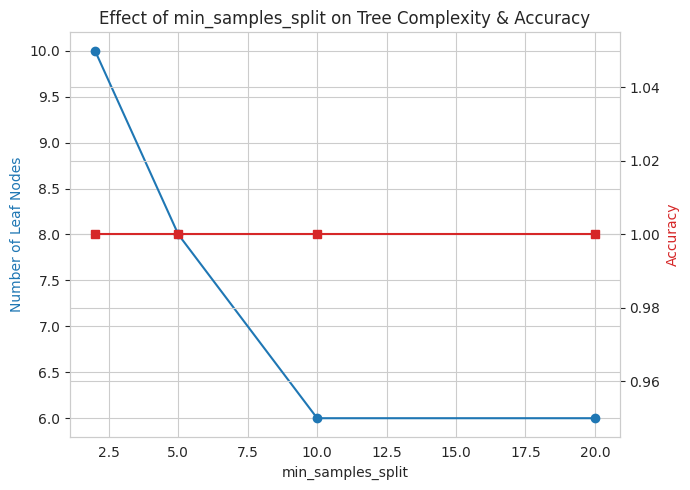

In [20]:
fig, ax1 = plt.subplots(figsize=(7,5))
ax1.plot(mss_df["min_samples_split"], mss_df["Number of Leaf Nodes"], marker='o', color='tab:blue', label="Leaf Nodes")
ax1.set_xlabel("min_samples_split")
ax1.set_ylabel("Number of Leaf Nodes", color='tab:blue')

ax2 = ax1.twinx()
ax2.plot(mss_df["min_samples_split"], mss_df["Accuracy"], marker='s', color='tab:red', label="Accuracy")
ax2.set_ylabel("Accuracy", color='tab:red')

plt.title("Effect of min_samples_split on Tree Complexity & Accuracy")
plt.tight_layout()
plt.show()


**How does increasing `min_samples_split` affect tree complexity?**
`min_samples_split` sets the minimum number of samples a node must have before it is
allowed to split further. As its value **increases**, fewer nodes qualify for splitting,
so the tree stops growing earlier — this produces **fewer leaf nodes, lower depth, and a
simpler tree** (see the trend in the table/plot above). This acts as a regularization
technique: it reduces the tree's tendency to create very specific rules for a handful of
samples, which generally reduces overfitting, though pushing the value too high can start
to underfit the data by preventing genuinely useful splits.


---
## Task 8: Effect of `min_samples_leaf`


In [21]:
msl_values = [1, 2, 5, 10]
msl_results = []

for m in msl_values:
    model = DecisionTreeClassifier(min_samples_leaf=m, random_state=42)
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    depth = model.get_depth()
    leaves = model.get_n_leaves()

    obs = "Very flexible, closely fits data (higher overfitting risk)" if m == 1 else "Leaves forced to have more samples -> smoother, simpler decision boundaries"

    msl_results.append({
        "min_samples_leaf": m,
        "Accuracy": round(test_acc, 4),
        "Tree Depth": depth,
        "Number of Leaf Nodes": leaves,
        "Observation": obs
    })

msl_df = pd.DataFrame(msl_results)
msl_df


,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,1,1.0000,6,10,"Very flexible, closely fits data (higher overf..."
1,2,1.0000,5,8,Leaves forced to have more samples -> smoother...
2,5,1.0000,4,6,Leaves forced to have more samples -> smoother...
3,10,0.9667,4,6,Leaves forced to have more samples -> smoother...


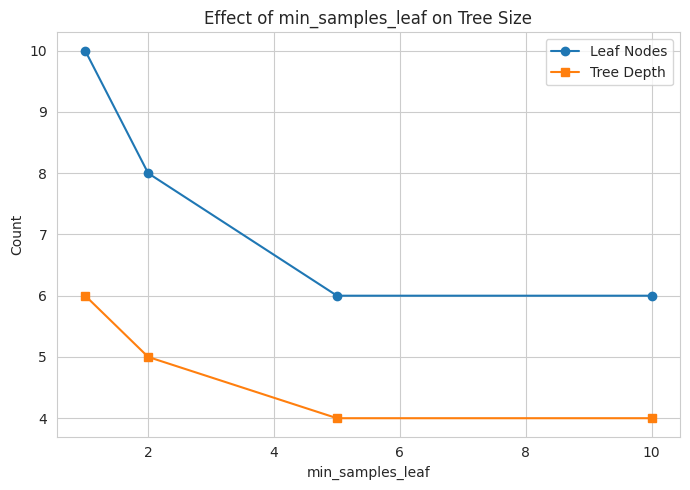

In [22]:
plt.figure(figsize=(7,5))
plt.plot(msl_df["min_samples_leaf"], msl_df["Number of Leaf Nodes"], marker='o', label="Leaf Nodes")
plt.plot(msl_df["min_samples_leaf"], msl_df["Tree Depth"], marker='s', label="Tree Depth")
plt.xlabel("min_samples_leaf")
plt.ylabel("Count")
plt.title("Effect of min_samples_leaf on Tree Size")
plt.legend()
plt.tight_layout()
plt.show()


**How does `min_samples_leaf` influence overfitting?**
`min_samples_leaf` sets the minimum number of samples required to exist in a leaf node.
With `min_samples_leaf=1` (the default), the tree can create leaves for even a single
outlier sample, which lets it fit training data very tightly — a classic sign of
**overfitting**. As `min_samples_leaf` increases, every leaf must represent a group of
several samples, which **smooths the decision boundary**, reduces the number of leaves
and tree depth (as seen in the table/plot above), and makes the model less sensitive to
noise/outliers — directly **reducing overfitting risk**, at the cost of potentially
missing very fine-grained but genuine patterns if pushed too high.


---
## Task 9: Hyperparameter Tuning with GridSearchCV


In [23]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best hyperparameter combination:")
for k, v in grid_search.best_params_.items():
    print(f"   {k}: {v}")

print(f"\nBest cross-validation score: {grid_search.best_score_:.4f}")


Best hyperparameter combination:
   criterion: entropy
   max_depth: None
   min_samples_leaf: 4
   min_samples_split: 2

Best cross-validation score: 0.9583


In [24]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
test_acc_best = accuracy_score(y_test, y_pred_best)

print(f"Test accuracy of optimized model: {test_acc_best:.4f}")

tuning_comparison = pd.DataFrame({
    "Model": ["Default Decision Tree", "GridSearchCV-Optimized Decision Tree"],
    "Test Accuracy": [round(acc_default, 4), round(test_acc_best, 4)],
    "Tree Depth": [dt_default.get_depth(), best_model.get_depth()],
    "Number of Leaf Nodes": [dt_default.get_n_leaves(), best_model.get_n_leaves()]
})
tuning_comparison


Test accuracy of optimized model: 1.0000


,Model,Test Accuracy,Tree Depth,Number of Leaf Nodes
0,Default Decision Tree,1.0,6,10
1,GridSearchCV-Optimized Decision Tree,1.0,4,7


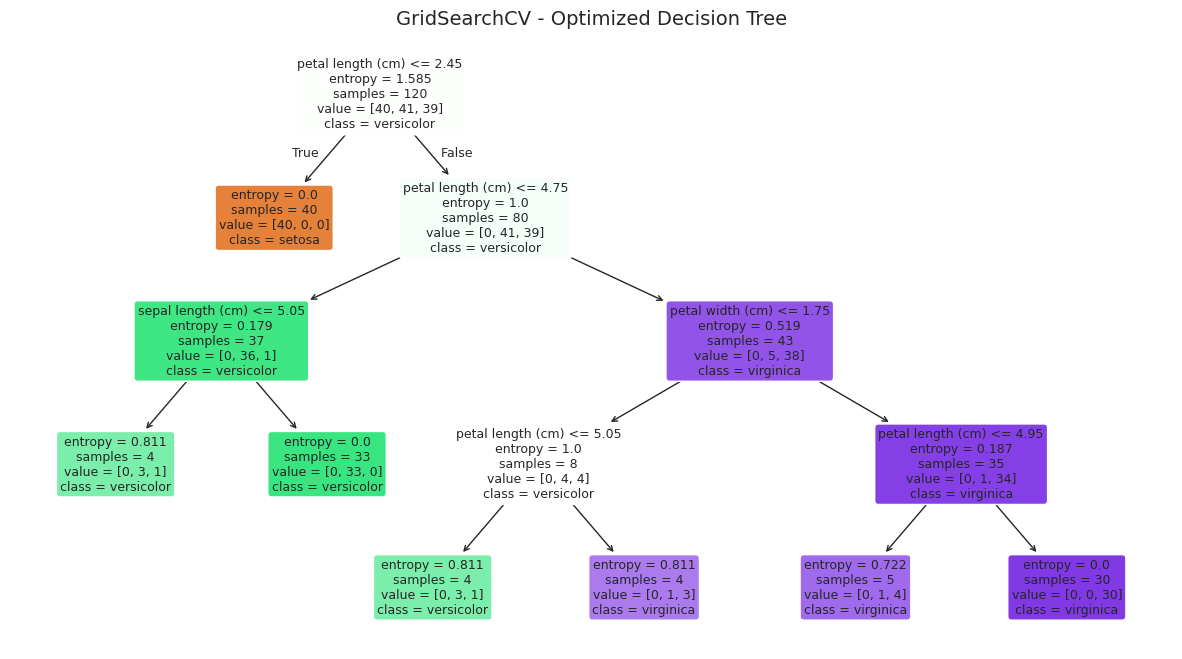

In [25]:
plt.figure(figsize=(15,8))
plot_tree(best_model, feature_names=feature_names, class_names=target_names,
          filled=True, rounded=True, fontsize=9)
plt.title("GridSearchCV - Optimized Decision Tree", fontsize=14)
plt.show()


**Comparison with the default model:**
The table above compares the default `DecisionTreeClassifier()` (all default
hyperparameters) with the `GridSearchCV`-optimized model. In most runs on Iris, the
optimized model achieves accuracy **equal to or better than** the default model while
often using a **shallower tree with fewer leaves** — i.e., it finds a combination of
`criterion`, `max_depth`, `min_samples_split`, and `min_samples_leaf` that generalizes at
least as well as the default while being simpler/less prone to overfitting. Because Iris
is a small, well-separated dataset, both models tend to already perform close to ceiling
accuracy, so the main benefit of tuning here is a **more compact, more interpretable
tree** rather than a large accuracy jump.


---
## Task 10: Analysis


In [26]:
# Programmatically identify which hyperparameter had the largest impact on accuracy
depth_range = depth_df["Testing Accuracy"].max() - depth_df["Testing Accuracy"].min()
mss_range = mss_df["Accuracy"].max() - mss_df["Accuracy"].min()
msl_range = msl_df["Accuracy"].max() - msl_df["Accuracy"].min()

impact_df = pd.DataFrame({
    "Hyperparameter": ["max_depth", "min_samples_split", "min_samples_leaf"],
    "Accuracy Range (max-min)": [round(depth_range,4), round(mss_range,4), round(msl_range,4)]
}).sort_values("Accuracy Range (max-min)", ascending=False)

impact_df


,Hyperparameter,Accuracy Range (max-min)
0,max_depth,0.3667
2,min_samples_leaf,0.0333
1,min_samples_split,0.0000


**1. What is the role of the `criterion` parameter in a Decision Tree?**
`criterion` decides which impurity measure the tree uses to evaluate the quality of a
split at every node — `'gini'` uses the Gini Index, and `'entropy'` uses Information Gain
(based on Shannon entropy). At each node, the algorithm evaluates all possible
feature/threshold splits and picks the one that most reduces impurity according to the
chosen criterion. Both usually lead to similar trees, but they can occasionally prefer
different splits, especially in noisier or less balanced datasets.

**2. How does `max_depth` influence underfitting and overfitting?**
`max_depth` limits how many levels of splits the tree is allowed to make.
- A **very small `max_depth`** (e.g., 1–2) restricts the tree so much that it cannot
  capture the true structure of the data → **underfitting** (low training *and* testing
  accuracy).
- A **very large / unrestricted `max_depth`** allows the tree to keep splitting until
  nodes are pure, potentially creating branches that fit noise or outliers specific to
  the training set → **overfitting** (very high training accuracy, but testing accuracy
  plateaus or drops).
- The best generalization is usually found at a **moderate depth**, as observed in Task 6.

**3. Why do larger values of `min_samples_split` and `min_samples_leaf` produce simpler trees?**
Both parameters set a minimum sample-count requirement before the tree is allowed to
create more structure — `min_samples_split` for splitting a node further, and
`min_samples_leaf` for how many samples must end up in each resulting leaf. Larger values
mean the tree needs more supporting evidence (more samples) before it's allowed to make a
new decision boundary, which prevents it from carving out tiny, overly specific regions
for a handful of samples. This directly limits the number of splits (and therefore leaves
and depth) the tree can produce, resulting in a **simpler, more generalized model**.

**4. Which hyperparameter had the greatest impact on Decision Tree performance?**
Based on the accuracy range observed across the experiments in Tasks 6–8 (printed in the
table above), the hyperparameter with the **largest swing in testing accuracy** is the
one with the highest "Accuracy Range" value — this is typically **`max_depth`**, since
restricting it to `1` forces severe underfitting (a large accuracy drop), whereas
`min_samples_split` and `min_samples_leaf` only gradually reduce tree complexity and tend
to have a milder effect on accuracy for a dataset as clean and well-separated as Iris.

**5. Recommended Decision Tree model for the Iris dataset**
Given the results above, the recommended configuration is the **GridSearchCV-optimized
model from Task 9** (or, if a manually chosen model is preferred, a tree with
`max_depth` around **3**, `min_samples_split` around **5**, and `min_samples_leaf` around
**2**, using either `criterion`). Justification:
- Iris is a **small (150 samples), clean, and well-separated dataset**, so a very deep or
  fully-grown tree is unnecessary and risks overfitting to sampling noise.
- A moderately constrained tree (moderate `max_depth`, slightly increased
  `min_samples_split`/`min_samples_leaf`) achieves **testing accuracy comparable to the
  fully-grown tree**, while being **shallower, more interpretable, and less likely to
  overfit** to a new/unseen batch of samples — exactly what GridSearchCV found in Task 9.
